In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('campus_gym_data.csv')
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [3]:
df.shape

(62184, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [5]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [6]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [7]:
df["date"] = pd.to_datetime(df["date"], utc=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [9]:
df["year"] = df["date"].dt.year
#df["month"] = df["month"].dt.year
#df["day"] = df["day"].dt.year
#df["hour"] = df["hour"].dt.year

In [10]:
df.year.unique()

array([2015, 2016, 2017], dtype=int32)

In [11]:
df.drop("date", axis=1, inplace=True)

In [12]:
df.tail()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
62179,23,67348,5,1,0,61.07,0,1,3,18,2017
62180,21,67955,5,1,0,61.07,0,1,3,18,2017
62181,25,68560,5,1,0,56.71,0,1,3,19,2017
62182,18,69167,5,1,0,56.71,0,1,3,19,2017
62183,23,69771,5,1,0,56.71,0,1,3,19,2017


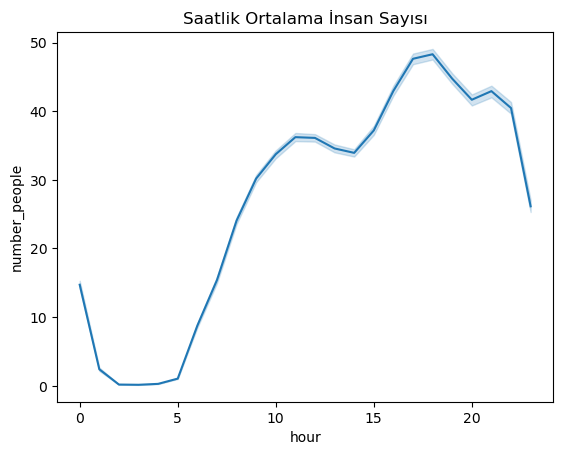

In [13]:
sns.lineplot(data=df, x="hour", y="number_people")
plt.title("Saatlik Ortalama İnsan Sayısı")
plt.show()

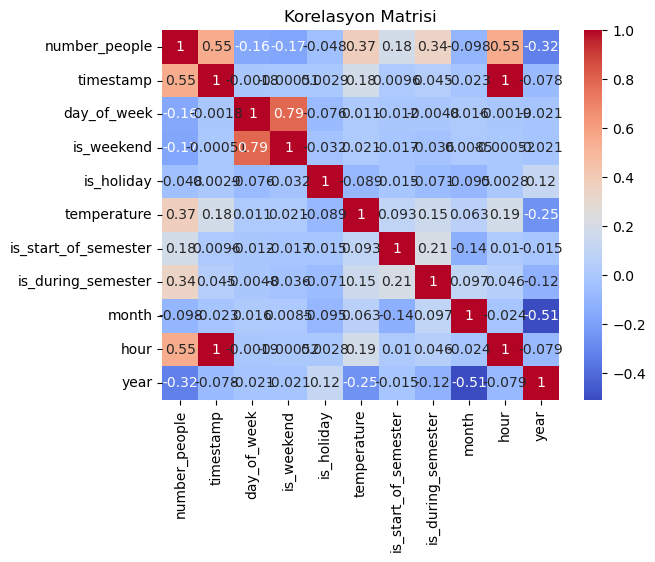

In [14]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

In [15]:
df.drop("timestamp", axis=1, inplace=True) # timestamp & hour arasındaki büyük korelasyon nedeniyle

In [16]:
# independent & dependent features

X=df.drop("number_people", axis=1)
y=df["number_people"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [18]:
# Ağaç tabanlı algoritmalarda scaler yapmaya gerek yok

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [21]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    score = r2_score(true, predicted)

    return mae, mse, rmse, score

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor()
}

In [23]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("MAE: ", model_train_mae)
    print("MSE: ", model_train_mse)
    print("RMSE: ", model_train_rmse)
    print("R2 Score: ", model_train_r2)

    print("------------------------")

    print("Evaluation for Test Set")
    print("MAE: ", model_test_mae)
    print("MSE: ", model_test_mse)
    print("RMSE: ", model_test_rmse)
    print("R2 Score: ", model_test_r2)

    print("------------------------")
    print("\n")

LinearRegression()
Evaluation for Training Set
MAE:  10.733469936454322
MSE:  205.13401794488652
RMSE:  14.322500408269727
R2 Score:  0.5999639521710997
------------------------
Evaluation for Test Set
MAE:  10.77975237102956
MSE:  208.82079130797558
RMSE:  14.45063290337055
R2 Score:  0.5989271376662775
------------------------


Lasso()
Evaluation for Training Set
MAE:  10.945189874221992
MSE:  212.259326082103
RMSE:  14.569122351126817
R2 Score:  0.5860687429058037
------------------------
Evaluation for Test Set
MAE:  10.970594902476913
MSE:  216.19324207171786
RMSE:  14.703511215751082
R2 Score:  0.5847671974050243
------------------------


Ridge()
Evaluation for Training Set
MAE:  10.733479178820698
MSE:  205.13401810651635
RMSE:  14.322500413912243
R2 Score:  0.5999639518559021
------------------------
Evaluation for Test Set
MAE:  10.77975955902301
MSE:  208.82080363770297
RMSE:  14.450633329986024
R2 Score:  0.5989271139851151
------------------------


KNeighborsRegressor()


In [24]:
# hyperparameter tuning

In [25]:
knn_params = {"n_neighbors": [2,3,10,20,40,50]}
rf_params = {
    "max_depth": [5,8,10,15,None],
    "max_features": ["sqrt", "log2", 5, 7, 10],
    "min_samples_split": [2, 8, 12, 20],
    "n_estimators": [100, 200, 500, 1000]
}

In [26]:
from sklearn.model_selection import RandomizedSearchCV

In [27]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)
]

In [28]:
for name, model, params in randomcv_models:
    print(name)
    print(model)
    print(params)
    print()

KNN
KNeighborsRegressor()
{'n_neighbors': [2, 3, 10, 20, 40, 50]}

RF
RandomForestRegressor()
{'max_depth': [5, 8, 10, 15, None], 'max_features': ['sqrt', 'log2', 5, 7, 10], 'min_samples_split': [2, 8, 12, 20], 'n_estimators': [100, 200, 500, 1000]}



In [29]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_jobs=-1)
    randomcv.fit(X_train, y_train)

    print("best params for :", name, randomcv.best_params_)

D:\Anaconda\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best params for : KNN {'n_neighbors': 2}
best params for : RF {'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 10, 'max_depth': 15}


In [30]:
models = {
    "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=2),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=1000,
                                                    min_samples_split=2,
                                                    max_features=10,
                                                    max_depth=15)
}

In [31]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("MAE: ", model_train_mae)
    print("MSE: ", model_train_mse)
    print("RMSE: ", model_train_rmse)
    print("R2 Score: ", model_train_r2)

    print("------------------------")

    print("Evaluation for Test Set")
    print("MAE: ", model_test_mae)
    print("MSE: ", model_test_mse)
    print("RMSE: ", model_test_rmse)
    print("R2 Score: ", model_test_r2)

    print("------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
MAE:  3.5543762597023885
MSE:  29.81083022428063
RMSE:  5.459929507262949
R2 Score:  0.9418652897023468
------------------------
Evaluation for Test Set
MAE:  4.6316737424417855
MSE:  47.63064453878811
RMSE:  6.901495818935785
R2 Score:  0.9085179266857696
------------------------


RandomForestRegressor(max_depth=15, max_features=10, n_estimators=1000)
Evaluation for Training Set
MAE:  3.9362574909314807
MSE:  34.52516320730077
RMSE:  5.87581170624968
R2 Score:  0.9326717724419211
------------------------
Evaluation for Test Set
MAE:  4.686932819703282
MSE:  49.49885170690418
RMSE:  7.035542033624999
R2 Score:  0.9049297437675101
------------------------


